# Preprocessing Data NO<sub>2</sub> Kabupaten Bangkalan

## **Penanganan Missing Values**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Penjelasan:**
- pandas: Library untuk manipulasi dan analisis data
- matplotlib.pyplot: Library untuk visualisasi data dan grafik

In [2]:
NO2 = pd.read_csv('no2_results/no2_bangkalan_data.csv')
NO2 = NO2.sort_values(by='date')
NO2

,date,feature_index,NO2
200,2024-12-31T00:00:00.000Z,0,NaN
197,2025-01-01T00:00:00.000Z,0,NaN
195,2025-01-02T00:00:00.000Z,0,NaN
198,2025-01-03T00:00:00.000Z,0,0.000040
194,2025-01-04T00:00:00.000Z,0,NaN
...,...,...,...
167,2025-09-26T00:00:00.000Z,0,0.000019
161,2025-09-27T00:00:00.000Z,0,0.000017
166,2025-09-28T00:00:00.000Z,0,0.000017
193,2025-09-29T00:00:00.000Z,0,0.000028


**Penjelasan:**
- Memuat dataset NO₂ dari file CSV hasil pengambilan data satelit
- Mengurutkan data berdasarkan tanggal untuk memastikan urutan temporal yang benar
- Menampilkan dataset untuk inspeksi awal

In [3]:
NO2.isnull().sum()

date               0
feature_index      0
NO2              102
dtype: int64

**Penjelasan:** Menghitung jumlah missing values pada setiap kolom untuk mengidentifikasi tingkat kelengkapan data.

C:\Users\Harits Putra Junaidi\AppData\Local\Temp\ipykernel_2252\800750193.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",


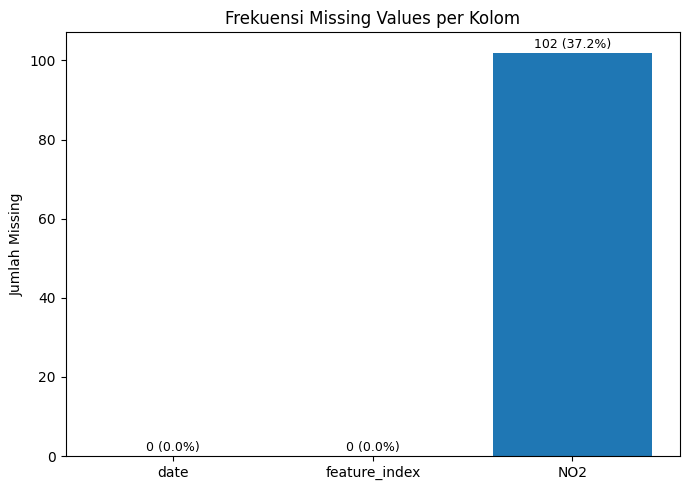

,Missing Count,Missing Percent (%)
date,0,0.00
feature_index,0,0.00
NO2,102,37.23


In [4]:
missing_count = NO2.isnull().sum()
missing_percent = (missing_count / len(NO2)) * 100

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(missing_count.index, missing_count)

ax.set_title("Frekuensi Missing Values per Kolom")
ax.set_ylabel("Jumlah Missing")

for i, v in enumerate(missing_count):
    ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table

**Penjelasan:**
- Membuat visualisasi bar chart untuk missing values
- Menampilkan jumlah dan persentase missing values di atas setiap bar
- Membuat tabel summary missing values untuk dokumentasi

In [5]:
NO2 = pd.Series(NO2['NO2'].values, index=NO2['date'], name='NO2')
NO2 = NO2.interpolate(method='linear').bfill()
NO2 = pd.DataFrame(NO2).reset_index()
NO2

,date,NO2
0,2024-12-31T00:00:00.000Z,0.000040
1,2025-01-01T00:00:00.000Z,0.000040
2,2025-01-02T00:00:00.000Z,0.000040
3,2025-01-03T00:00:00.000Z,0.000040
4,2025-01-04T00:00:00.000Z,0.000038
...,...,...
269,2025-09-26T00:00:00.000Z,0.000019
270,2025-09-27T00:00:00.000Z,0.000017
271,2025-09-28T00:00:00.000Z,0.000017
272,2025-09-29T00:00:00.000Z,0.000028


**Penjelasan:**
- Konversi ke Series: Mengubah data menjadi pandas Series dengan index tanggal
- Linear Interpolation: Mengisi missing values dengan interpolasi linear berdasarkan nilai sebelum dan sesudahnya
- Backward Fill: Mengisi missing values yang tersisa dengan nilai valid berikutnya
- Konversi kembali: Mengubah kembali ke DataFrame dan reset index
- Metode ini mempertahankan pola temporal data

In [6]:
NO2.isnull().sum()

date    0
NO2     0
dtype: int64

**Penjelasan:** Memverifikasi bahwa semua missing values telah berhasil ditangani setelah proses interpolasi dan backward fill.

In [7]:
missing_count = NO2.isnull().sum()
missing_percent = (missing_count / len(NO2)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table

,Missing Count,Missing Percent (%)
date,0,0.0
NO2,0,0.0


**Penjelasan:** Membuat tabel summary untuk mendokumentasikan bahwa tidak ada lagi missing values setelah proses imputasi.

In [8]:
NO2 = NO2.drop(columns='date')
NO2 = pd.DataFrame(NO2)
NO2

,NO2
0,0.000040
1,0.000040
2,0.000040
3,0.000040
4,0.000038
...,...
269,0.000019
270,0.000017
271,0.000017
272,0.000028


**Penjelasan:**
- Menghapus kolom 'date' karena tidak diperlukan untuk modeling time series
- Memastikan data dalam format DataFrame yang bersih
- Memfokuskan data hanya pada nilai NO₂ untuk proses supervised learning

## **Deteksi Dan Penanganan Outlier Menggunakan LOF**

Outlier terdeteksi: 28 dari 274 data (10.22%)
NO2: 0 nilai < -0.000006 dan 4 nilai > 0.000060


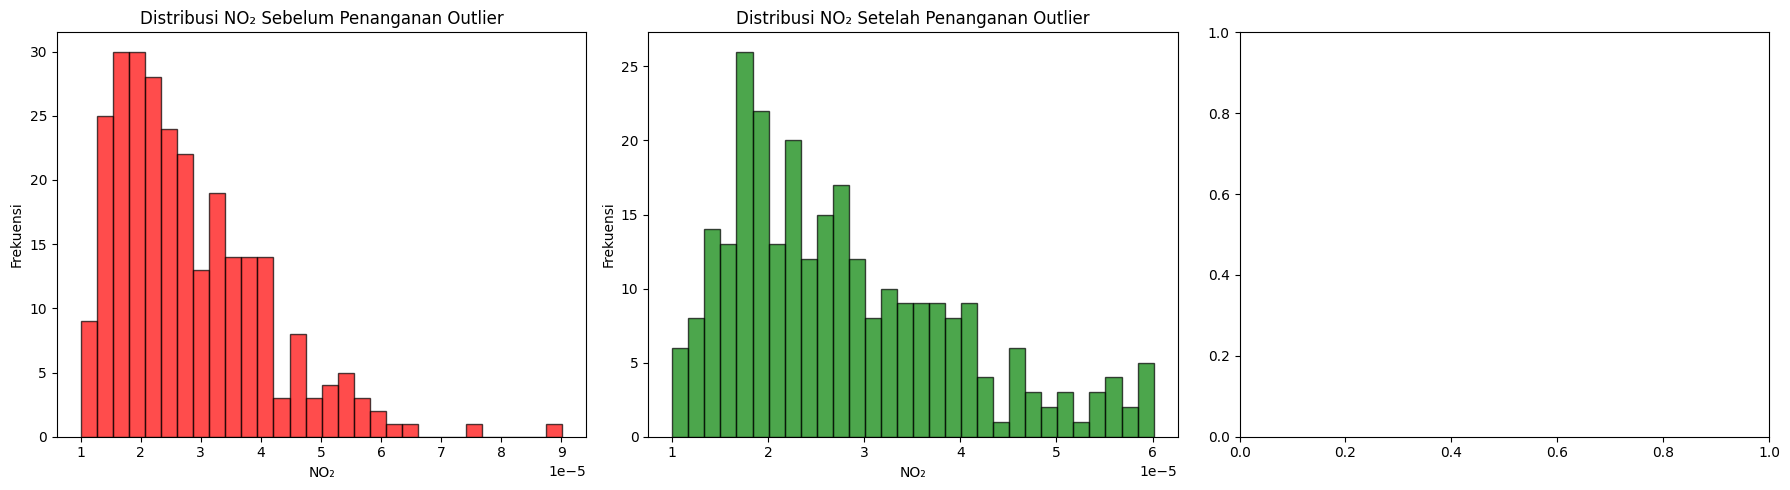

In [9]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

# Deteksi outlier menggunakan LOF pada kolom NO2
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
outlier_labels = lof.fit_predict(NO2[['NO2']])

# Identifikasi outlier
outlier_mask = outlier_labels == -1
n_outliers_before = sum(outlier_mask)

print(f"Outlier terdeteksi: {n_outliers_before} dari {len(NO2)} data ({(n_outliers_before/len(NO2)*100):.2f}%)")

# Visualisasi outlier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Distribusi sebelum penanganan
axes[0].hist(NO2['NO2'], bins=30, alpha=0.7, color='red', edgecolor='black')
axes[0].set_title('Distribusi NO₂ Sebelum Penanganan Outlier')
axes[0].set_xlabel('NO₂')
axes[0].set_ylabel('Frekuensi')


# Penanganan outlier menggunakan IQR capping
Q1 = NO2['NO2'].quantile(0.25)
Q3 = NO2['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Hitung outlier sebelum capping
outlier_count_lower = sum(NO2['NO2'] < lower_bound)
outlier_count_upper = sum(NO2['NO2'] > upper_bound)

print(f"NO2: {outlier_count_lower} nilai < {lower_bound:.6f} dan {outlier_count_upper} nilai > {upper_bound:.6f}")

# Capping outlier
NO2['NO2'] = np.clip(NO2['NO2'], lower_bound, upper_bound)


# Distribusi setelah penanganan
axes[1].hist(NO2['NO2'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Distribusi NO₂ Setelah Penanganan Outlier')
axes[1].set_xlabel('NO₂')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Verifikasi hasil
lof_verify = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
outlier_labels_after = lof_verify.fit_predict(NO2[['NO2']])
n_outliers_after = sum(outlier_labels_after == -1)

# print(f"\nHasil setelah penanganan outlier:")
# print(f"Outlier tersisa: {n_outliers_after} dari {len(NO2)} data ({(n_outliers_after/len(NO2)*100):.2f}%)")
# print(f"Pengurangan outlier: {n_outliers_before - n_outliers_after} data")
# print("✓ Outlier telah ditangani, data siap untuk supervised learning\n")

## **Membentuk data supervised**

In [10]:
output_dir = "no2_results"

In [11]:
day1 = NO2
day2 = NO2
day3 = NO2
day4 = NO2
day5 = NO2

### - Membuat data supervised menggunakan t1

In [12]:
n_lags = 1
n_steps = 3
day1_copy = day1.copy()

for i in range(1, n_lags + 1):
    day1_copy[f"t-{i}"] = day1_copy["NO2"].shift(i)

for j in range(1, n_steps + 1):
    day1_copy[f"NO2_t+{j}"] = day1_copy["NO2"].shift(-j)

day1_copy = day1_copy.dropna().reset_index(drop=True)
ordered_cols = [f"t-{i}" for i in range(n_lags, 0, -1)] + [f"NO2_t+{j}" for j in range(1, n_steps + 1)]
day1_copy = day1_copy[ordered_cols]
day1_copy.to_csv(f"{output_dir}/day1_supervised.csv", index=False)
print("✅ day1_supervised.csv disimpan:", day1_copy.shape)
day1_copy

✅ day1_supervised.csv disimpan: (270, 4)


,t-1,NO2_t+1,NO2_t+2,NO2_t+3
0,0.000040,0.000040,0.000040,0.000038
1,0.000040,0.000040,0.000038,0.000036
2,0.000040,0.000038,0.000036,0.000034
3,0.000040,0.000036,0.000034,0.000039
4,0.000038,0.000034,0.000039,0.000022
...,...,...,...,...
265,0.000022,0.000051,0.000018,0.000019
266,0.000047,0.000018,0.000019,0.000017
267,0.000051,0.000019,0.000017,0.000017
268,0.000018,0.000017,0.000017,0.000028


### - Membuat data supervised menggunakan t1, t2

In [13]:
n_lags = 2
day2_copy = day2.copy()

for i in range(1, n_lags + 1):
    day2_copy[f"t-{i}"] = day2_copy["NO2"].shift(i)

for j in range(1, n_steps + 1):
    day2_copy[f"NO2_t+{j}"] = day2_copy["NO2"].shift(-j)

day2_copy = day2_copy.dropna().reset_index(drop=True)
ordered_cols = [f"t-{i}" for i in range(n_lags, 0, -1)] + [f"NO2_t+{j}" for j in range(1, n_steps + 1)]
day2_copy = day2_copy[ordered_cols]
day2_copy.to_csv(f"{output_dir}/day2_supervised.csv", index=False)
print("✅ day2_supervised.csv disimpan:", day2_copy.shape)
day2_copy

✅ day2_supervised.csv disimpan: (269, 5)


,t-2,t-1,NO2_t+1,NO2_t+2,NO2_t+3
0,0.000040,0.000040,0.000040,0.000038,0.000036
1,0.000040,0.000040,0.000038,0.000036,0.000034
2,0.000040,0.000040,0.000036,0.000034,0.000039
3,0.000040,0.000038,0.000034,0.000039,0.000022
4,0.000038,0.000036,0.000039,0.000022,0.000034
...,...,...,...,...,...
264,0.000010,0.000022,0.000051,0.000018,0.000019
265,0.000022,0.000047,0.000018,0.000019,0.000017
266,0.000047,0.000051,0.000019,0.000017,0.000017
267,0.000051,0.000018,0.000017,0.000017,0.000028


### - Membuat data supervised menggunakan t1, t2, t3

In [14]:
n_lags = 3
day3_copy = day3.copy()

for i in range(1, n_lags + 1):
    day3_copy[f"t-{i}"] = day3_copy["NO2"].shift(i)

for j in range(1, n_steps + 1):
    day3_copy[f"NO2_t+{j}"] = day3_copy["NO2"].shift(-j)

day3_copy = day3_copy.dropna().reset_index(drop=True)
ordered_cols = [f"t-{i}" for i in range(n_lags, 0, -1)] + [f"NO2_t+{j}" for j in range(1, n_steps + 1)]
day3_copy = day3_copy[ordered_cols]
day3_copy.to_csv(f"{output_dir}/day3_supervised.csv", index=False)
print("✅ day3_supervised.csv disimpan:", day3_copy.shape)
day3_copy

✅ day3_supervised.csv disimpan: (268, 6)


,t-3,t-2,t-1,NO2_t+1,NO2_t+2,NO2_t+3
0,0.000040,0.000040,0.000040,0.000038,0.000036,0.000034
1,0.000040,0.000040,0.000040,0.000036,0.000034,0.000039
2,0.000040,0.000040,0.000038,0.000034,0.000039,0.000022
3,0.000040,0.000038,0.000036,0.000039,0.000022,0.000034
4,0.000038,0.000036,0.000034,0.000022,0.000034,0.000038
...,...,...,...,...,...,...
263,0.000011,0.000010,0.000022,0.000051,0.000018,0.000019
264,0.000010,0.000022,0.000047,0.000018,0.000019,0.000017
265,0.000022,0.000047,0.000051,0.000019,0.000017,0.000017
266,0.000047,0.000051,0.000018,0.000017,0.000017,0.000028


### - Membuat data supervised menggunakan t1, t2, t3, t4

In [15]:
n_lags = 4
day4_copy = day4.copy()

for i in range(1, n_lags + 1):
    day4_copy[f"t-{i}"] = day4_copy["NO2"].shift(i)

for j in range(1, n_steps + 1):
    day4_copy[f"NO2_t+{j}"] = day4_copy["NO2"].shift(-j)

day4_copy = day4_copy.dropna().reset_index(drop=True)
ordered_cols = [f"t-{i}" for i in range(n_lags, 0, -1)] + [f"NO2_t+{j}" for j in range(1, n_steps + 1)]
day4_copy = day4_copy[ordered_cols]
day4_copy.to_csv(f"{output_dir}/day4_supervised.csv", index=False)
print("✅ day4_supervised.csv disimpan:", day4_copy.shape)
day4_copy

✅ day4_supervised.csv disimpan: (267, 7)


,t-4,t-3,t-2,t-1,NO2_t+1,NO2_t+2,NO2_t+3
0,0.000040,0.000040,0.000040,0.000040,0.000036,0.000034,0.000039
1,0.000040,0.000040,0.000040,0.000038,0.000034,0.000039,0.000022
2,0.000040,0.000040,0.000038,0.000036,0.000039,0.000022,0.000034
3,0.000040,0.000038,0.000036,0.000034,0.000022,0.000034,0.000038
4,0.000038,0.000036,0.000034,0.000039,0.000034,0.000038,0.000042
...,...,...,...,...,...,...,...
262,0.000011,0.000011,0.000010,0.000022,0.000051,0.000018,0.000019
263,0.000011,0.000010,0.000022,0.000047,0.000018,0.000019,0.000017
264,0.000010,0.000022,0.000047,0.000051,0.000019,0.000017,0.000017
265,0.000022,0.000047,0.000051,0.000018,0.000017,0.000017,0.000028


### - Membuat data supervised menggunakan t1, t2, t3, t4, t5

In [16]:
n_lags = 5
day5_copy = day5.copy()

for i in range(1, n_lags + 1):
    day5_copy[f"t-{i}"] = day5_copy["NO2"].shift(i)

for j in range(1, n_steps + 1):
    day5_copy[f"NO2_t+{j}"] = day5_copy["NO2"].shift(-j)

day5_copy = day5_copy.dropna().reset_index(drop=True)
ordered_cols = [f"t-{i}" for i in range(n_lags, 0, -1)] + [f"NO2_t+{j}" for j in range(1, n_steps + 1)]
day5_copy = day5_copy[ordered_cols]
day5_copy.to_csv(f"{output_dir}/day5_supervised.csv", index=False)
print("✅ day5_supervised.csv disimpan:", day5_copy.shape)
day5_copy

✅ day5_supervised.csv disimpan: (266, 8)


,t-5,t-4,t-3,t-2,t-1,NO2_t+1,NO2_t+2,NO2_t+3
0,0.000040,0.000040,0.000040,0.000040,0.000038,0.000034,0.000039,0.000022
1,0.000040,0.000040,0.000040,0.000038,0.000036,0.000039,0.000022,0.000034
2,0.000040,0.000040,0.000038,0.000036,0.000034,0.000022,0.000034,0.000038
3,0.000040,0.000038,0.000036,0.000034,0.000039,0.000034,0.000038,0.000042
4,0.000038,0.000036,0.000034,0.000039,0.000022,0.000038,0.000042,0.000042
...,...,...,...,...,...,...,...,...
261,0.000017,0.000011,0.000011,0.000010,0.000022,0.000051,0.000018,0.000019
262,0.000011,0.000011,0.000010,0.000022,0.000047,0.000018,0.000019,0.000017
263,0.000011,0.000010,0.000022,0.000047,0.000051,0.000019,0.000017,0.000017
264,0.000010,0.000022,0.000047,0.000051,0.000018,0.000017,0.000017,0.000028


## **Korelasi lag features dengan NO2**

DAY1: threshold = 0.357 (35.7%)
DAY2: threshold = 0.354 (35.4%)
DAY3: threshold = 0.352 (35.2%)
DAY4: threshold = 0.349 (34.9%)
DAY5: threshold = 0.348 (34.8%)

--- ANALISIS DATASET DAY1 (Threshold: 0.357) ---
  🟢 t-1: avg=0.288, max=0.357 - DIPILIH


  Dataset filtered disimpan: no2_results/day1_supervised_filtered.csv
  Features terpilih: 1/1

--- ANALISIS DATASET DAY2 (Threshold: 0.354) ---
  🔴 t-2: avg=0.253, max=0.259 - TIDAK DIPILIH
  🟢 t-1: avg=0.285, max=0.354 - DIPILIH
  Dataset filtered disimpan: no2_results/day2_supervised_filtered.csv
  Features terpilih: 1/2

--- ANALISIS DATASET DAY3 (Threshold: 0.352) ---
  🔴 t-3: avg=0.218, max=0.250 - TIDAK DIPILIH
  🔴 t-2: avg=0.250, max=0.256 - TIDAK DIPILIH
  🟢 t-1: avg=0.283, max=0.352 - DIPILIH


  Dataset filtered disimpan: no2_results/day3_supervised_filtered.csv
  Features terpilih: 1/3

--- ANALISIS DATASET DAY4 (Threshold: 0.349) ---
  🔴 t-4: avg=0.177, max=0.252 - TIDAK DIPILIH
  🔴 t-3: avg=0.216, max=0.249 - TIDAK DIPILIH
  🔴 t-2: avg=0.248, max=0.253 - TIDAK DIPILIH
  🟢 t-1: avg=0.281, max=0.349 - DIPILIH
  Dataset filtered disimpan: no2_results/day4_supervised_filtered.csv
  Features terpilih: 1/4

--- ANALISIS DATASET DAY5 (Threshold: 0.348) ---
  🔴 t-5: avg=0.125, max=0.156 - TIDAK DIPILIH
  🔴 t-4: avg=0.174, max=0.250 - TIDAK DIPILIH
  🔴 t-3: avg=0.214, max=0.247 - TIDAK DIPILIH
  🔴 t-2: avg=0.246, max=0.251 - TIDAK DIPILIH
  🟢 t-1: avg=0.279, max=0.348 - DIPILIH


  Dataset filtered disimpan: no2_results/day5_supervised_filtered.csv
  Features terpilih: 1/5


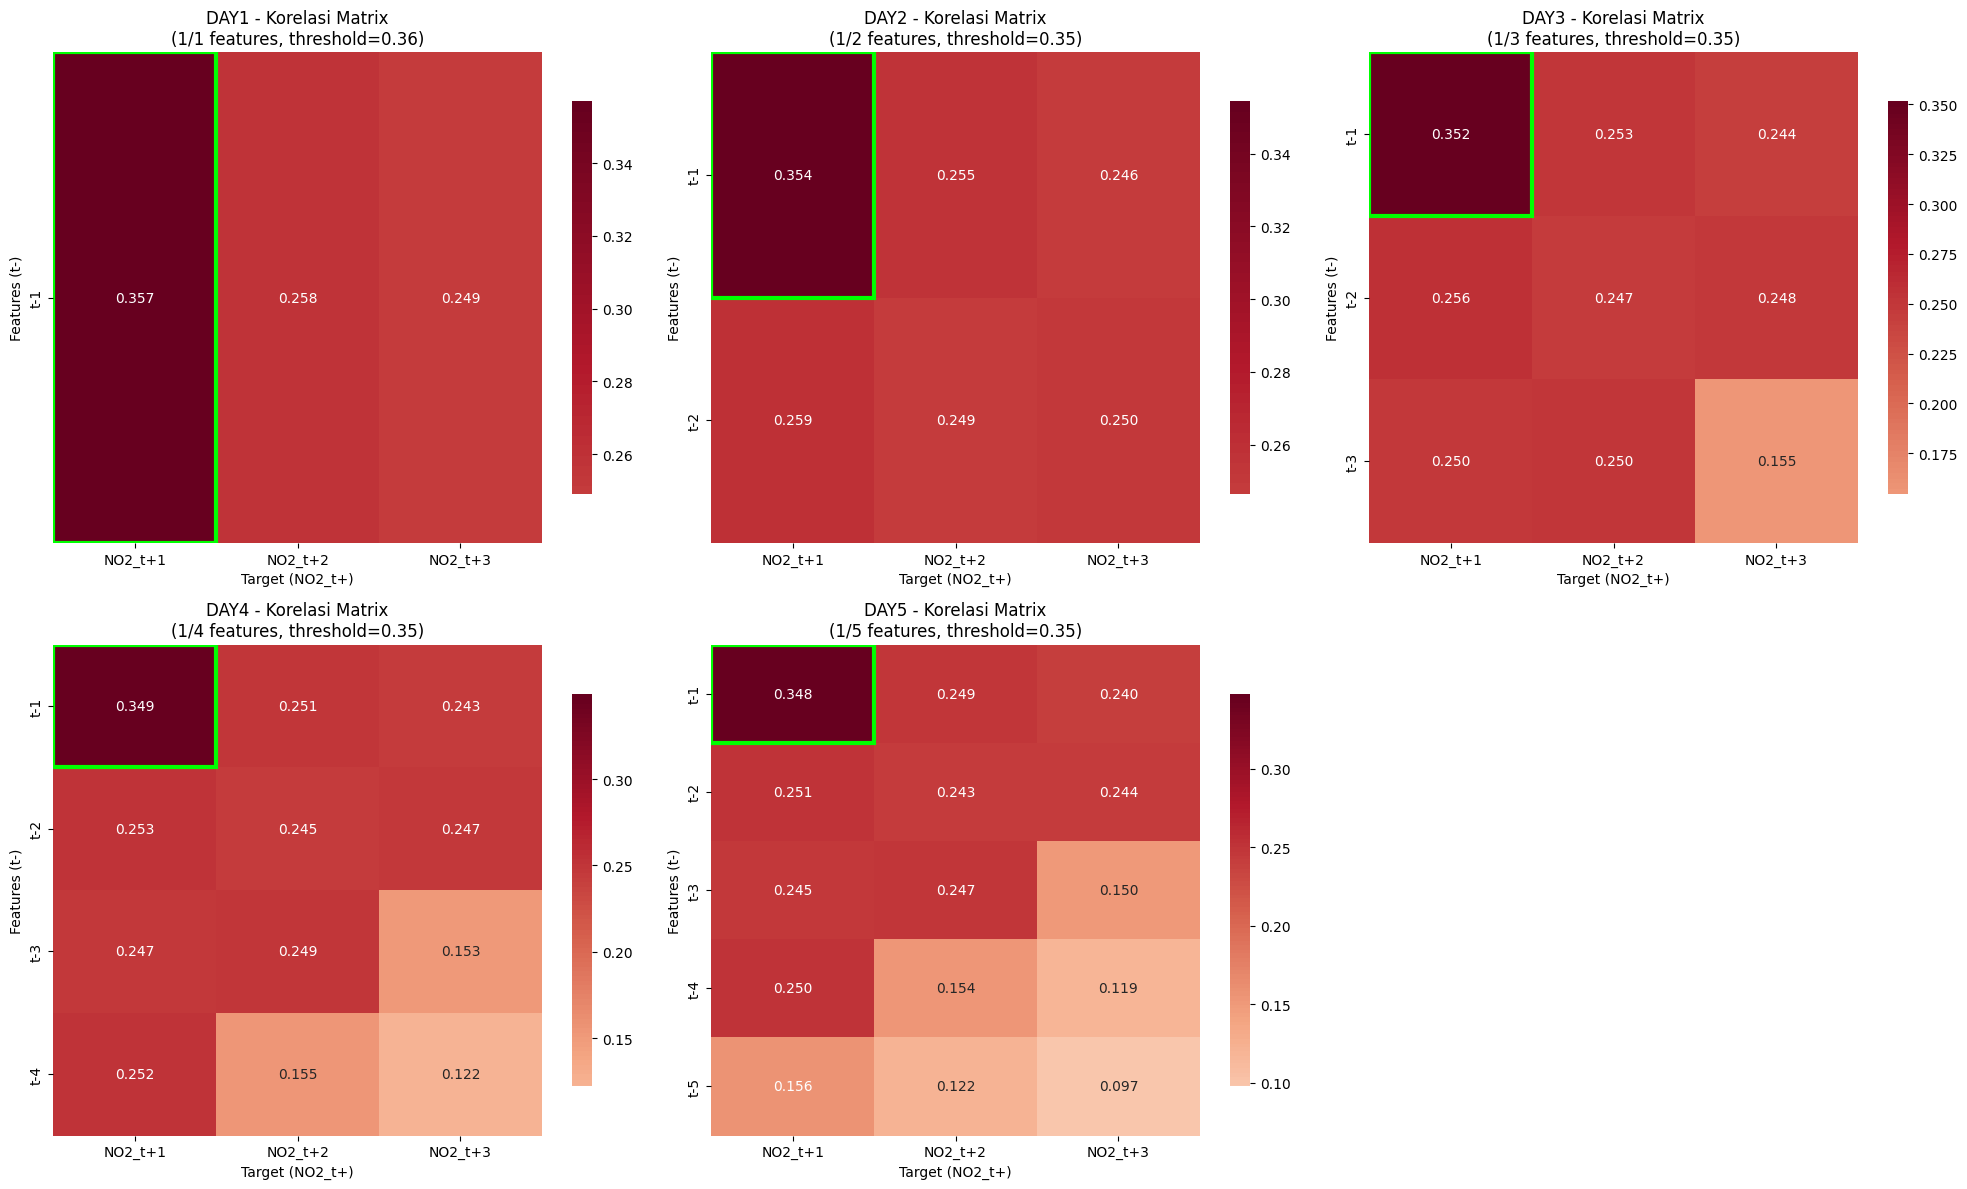

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_multioutput_correlations_adaptive(datasets_dict, min_features_per_dataset=1, output_dir="no2_results"):
    """
    Analisis korelasi dengan threshold adaptif untuk memastikan setiap dataset memiliki minimal features
    """
    results = {}
    optimal_thresholds = {}
    
    for dataset_name, file_path in datasets_dict.items():
        df = pd.read_csv(file_path)
        feature_columns = [col for col in df.columns if col.startswith('t-')]
        target_columns = [col for col in df.columns if col.startswith('NO2_t+')]
        
        # Kumpulkan semua korelasi
        all_correlations = []
        for feature in feature_columns:
            for target in target_columns:
                corr = abs(df[feature].corr(df[target]))
                all_correlations.append(corr)
        
        # Urutkan dari tertinggi ke terendah
        all_correlations.sort(reverse=True)
        
        if len(all_correlations) >= min_features_per_dataset:
            threshold = all_correlations[min_features_per_dataset-1]
            threshold = max(threshold, 0.2)
        else:
            threshold = 0.2
        
        optimal_thresholds[dataset_name] = threshold
        print(f"{dataset_name.upper()}: threshold = {threshold:.3f} ({threshold*100:.1f}%)")
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for idx, (dataset_name, file_path) in enumerate(datasets_dict.items()):
        if idx >= len(axes):
            break
        
        threshold = optimal_thresholds[dataset_name]
        
        print(f"\n--- ANALISIS DATASET {dataset_name.upper()} (Threshold: {threshold:.3f}) ---")
        
        df = pd.read_csv(file_path)
        feature_columns = [col for col in df.columns if col.startswith('t-')]
        target_columns = [col for col in df.columns if col.startswith('NO2_t+')]
        
        correlations = {}
        selected_features = []
        correlation_matrix = []
        
        for feature in feature_columns:
            feature_correlations = {}
            feature_selected = False
            
            for target in target_columns:
                correlation = df[feature].corr(df[target])
                abs_correlation = abs(correlation)
                
                feature_correlations[target] = {
                    'correlation': correlation,
                    'abs_correlation': abs_correlation
                }
                
                if abs_correlation >= threshold:
                    feature_selected = True
                
                correlation_matrix.append([feature, target, correlation])
            
            correlations[feature] = feature_correlations
            
            if feature_selected:
                selected_features.append(feature)
                status = "DIPILIH"
                symbol = "🟢"
            else:
                status = "TIDAK DIPILIH"
                symbol = "🔴"
            
            avg_corr = np.mean([v['abs_correlation'] for v in feature_correlations.values()])
            max_corr = max([v['abs_correlation'] for v in feature_correlations.values()])
            
            print(f"  {symbol} {feature}: avg={avg_corr:.3f}, max={max_corr:.3f} - {status}")
        
        # pilih yang korelasi tertinggi
        if not selected_features and feature_columns:
            # Cari feature dengan korelasi maksimum tertinggi
            best_feature = None
            best_max_corr = 0
            
            for feature in feature_columns:
                max_corr = max([correlations[feature][target]['abs_correlation'] 
                              for target in target_columns])
                if max_corr > best_max_corr:
                    best_max_corr = max_corr
                    best_feature = feature
            
            if best_feature:
                selected_features.append(best_feature)
                print(f" Dipilih: {best_feature} (korelasi tertinggi: {best_max_corr:.3f})")
        
        # Filter dataset
        final_columns = selected_features + target_columns
        df_filtered = df[final_columns].copy()
        
        # Simpan dataset yang sudah difilter
        filtered_filename = f'{output_dir}/{dataset_name}_supervised_filtered.csv'
        df_filtered.to_csv(filtered_filename, index=False)
        
        # Visualisasi heatmap
        if correlation_matrix:
            corr_df = pd.DataFrame(correlation_matrix, columns=['Feature', 'Target', 'Correlation'])
            pivot_table = corr_df.pivot(index='Feature', columns='Target', values='Correlation')
            
            ax = axes[idx]
            sns.heatmap(pivot_table, annot=True, cmap='RdBu_r', center=0, 
                       ax=ax, cbar_kws={'shrink': 0.8}, fmt='.3f')
            ax.set_title(f'{dataset_name.upper()} - Korelasi Matrix\n({len(selected_features)}/{len(feature_columns)} features, threshold={threshold:.2f})')
            ax.set_xlabel('Target (NO2_t+)')
            ax.set_ylabel('Features (t-)')
            
            for i, feature in enumerate(pivot_table.index):
                if feature in selected_features:
                    for j in range(len(pivot_table.columns)):
                        val = pivot_table.iloc[i, j]
                        if abs(val) >= threshold:
                            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, 
                                                     edgecolor='lime', linewidth=3))
        
        # Simpan hasil
        results[dataset_name] = {
            'original_file': file_path,
            'filtered_file': filtered_filename,
            'feature_columns': feature_columns,
            'target_columns': target_columns,
            'selected_features': selected_features,
            'correlations': correlations,
            'n_features_total': len(feature_columns),
            'n_features_selected': len(selected_features),
            'threshold_used': threshold,
            'filtered_df': df_filtered
        }
        
        print(f"  Dataset filtered disimpan: {filtered_filename}")
        print(f"  Features terpilih: {len(selected_features)}/{len(feature_columns)}")

    # Hapus subplot yang tidak digunakan
    for idx in range(len(datasets_dict), len(axes)):
        axes[idx].remove()
    
    plt.tight_layout()
    plt.show()
    
    return results

# Dataset yang akan dianalisis
supervised_datasets = {
    'day1': f'{output_dir}/day1_supervised.csv',
    'day2': f'{output_dir}/day2_supervised.csv', 
    'day3': f'{output_dir}/day3_supervised.csv',
    'day4': f'{output_dir}/day4_supervised.csv',
    'day5': f'{output_dir}/day5_supervised.csv'
}

correlation_results = analyze_multioutput_correlations_adaptive(supervised_datasets, min_features_per_dataset=1, output_dir=output_dir)

In [18]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np


# def analyze_multioutput_correlations(datasets_dict, correlation_threshold=0.5, output_dir="no2_results"):

#     results = {}
    
#     fig, axes = plt.subplots(2, 3, figsize=(20, 12))
#     axes = axes.flatten()
    
#     for idx, (dataset_name, file_path) in enumerate(datasets_dict.items()):
#         if idx >= len(axes):
#             break
            
#         print(f"\n--- ANALISIS DATASET {dataset_name.upper()} ---")
        
#         # Baca dataset
#         df = pd.read_csv(file_path)
        
#         # Identifikasi kolom features dan targets
#         feature_columns = [col for col in df.columns if col.startswith('t-')]
#         target_columns = [col for col in df.columns if col.startswith('NO2_t+')]
        
#         if not feature_columns or not target_columns:
#             print(f"Dataset {dataset_name} tidak memiliki format yang sesuai")
#             continue
        
#         print(f"Features: {feature_columns}")
#         print(f"Targets: {target_columns}")
        
#         # Hitung korelasi untuk setiap kombinasi feature-target
#         correlations = {}
#         selected_features = []
#         correlation_matrix = []
        
#         print(f"\nANALISIS KORELASI (Threshold: {correlation_threshold*100}%):")
#         print("-" * 70)
        
#         for feature in feature_columns:
#             feature_correlations = {}
#             feature_selected = False
            
#             for target in target_columns:
#                 correlation = df[feature].corr(df[target])
#                 abs_correlation = abs(correlation)
                
#                 feature_correlations[target] = {
#                     'correlation': correlation,
#                     'abs_correlation': abs_correlation
#                 }
                
#                 # Cek korelasi memenuhi threshold
#                 if abs_correlation >= correlation_threshold:
#                     feature_selected = True
                
#                 # Untuk visualisasi
#                 correlation_matrix.append([feature, target, correlation])
            
#             correlations[feature] = feature_correlations
            
#             if feature_selected:
#                 selected_features.append(feature)
#                 status = "DIPILIH"
#                 symbol = "🟢"
#             else:
#                 status = "TIDAK DIPILIH"
#                 symbol = "🔴"
            
#             avg_corr = np.mean([v['abs_correlation'] for v in feature_correlations.values()])
#             max_corr = max([v['abs_correlation'] for v in feature_correlations.values()])
            
#             print(f"{symbol} {feature}: avg={avg_corr:.3f}, max={max_corr:.3f} - {status}")
        
#         # Filter dataset berdasarkan selected features
#         final_columns = selected_features + target_columns
#         df_filtered = df[final_columns].copy()
        
#         # Simpan dataset yang sudah difilter
#         filtered_filename = f'{output_dir}/{dataset_name}_supervised_filtered.csv'
#         df_filtered.to_csv(filtered_filename, index=False)
        
#         # Visualisasi heatmap korelasi
#         if correlation_matrix:
#             corr_df = pd.DataFrame(correlation_matrix, columns=['Feature', 'Target', 'Correlation'])
#             pivot_table = corr_df.pivot(index='Feature', columns='Target', values='Correlation')
            
#             # Plot heatmap
#             ax = axes[idx]
#             sns.heatmap(pivot_table, annot=True, cmap='RdBu_r', center=0, 
#                        ax=ax, cbar_kws={'shrink': 0.8}, fmt='.3f')
#             ax.set_title(f'{dataset_name.upper()} - Korelasi Matrix\n({len(selected_features)}/{len(feature_columns)} features terpilih)')
#             ax.set_xlabel('Target (NO2_t+)')
#             ax.set_ylabel('Features (t-)')
            
#             # garis threshold
#             for i in range(len(pivot_table.index)):
#                 for j in range(len(pivot_table.columns)):
#                     val = pivot_table.iloc[i, j]
#                     if abs(val) >= correlation_threshold:
#                         ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, 
#                                                  edgecolor='lime', linewidth=3))
        
#         # Simpan hasil
#         results[dataset_name] = {
#             'original_file': file_path,
#             'filtered_file': filtered_filename,
#             'feature_columns': feature_columns,
#             'target_columns': target_columns,
#             'selected_features': selected_features,
#             'correlations': correlations,
#             'n_features_total': len(feature_columns),
#             'n_features_selected': len(selected_features),
#             'filtered_df': df_filtered
#         }
        
#         print(f"Dataset filtered disimpan: {filtered_filename}")
#         print(f"Features terpilih: {len(selected_features)}/{len(feature_columns)}")

#     for idx in range(len(datasets_dict), len(axes)):
#         axes[idx].remove()
    
#     plt.tight_layout()
#     plt.show()
    
#     return results

# # Dataset yang akan dianalisis
# supervised_datasets = {
#     'day1': f'{output_dir}/day1_supervised.csv',
#     'day2': f'{output_dir}/day2_supervised.csv', 
#     'day3': f'{output_dir}/day3_supervised.csv',
#     'day4': f'{output_dir}/day4_supervised.csv',
#     'day5': f'{output_dir}/day5_supervised.csv'
# }

# # korelasi dengan threshold 0.5
# correlation_threshold = 0.5
# correlation_results = analyze_multioutput_correlations(supervised_datasets, correlation_threshold, output_dir)